# Fine-Tuning an LLM for Paid Search Bid & Budget Recommendations

## What We Are Building

This notebook walks through the complete pipeline for **fine-tuning a large language model on a custom paid search dataset** so that it can generate intelligent, actionable bid and budget recommendations for Google/Bing Ads campaigns.

### The Problem

Paid search campaign managers handle hundreds or thousands of keywords, each with its own performance signals: click-through rate (CTR), conversion rate (CVR), return on ad spend (ROAS), Quality Score, and more. Making the right bid adjustment for each keyword requires synthesizing all of these signals simultaneously — a task that is tedious at scale and prone to human inconsistency.

### The Solution

We fine-tune a 7B-parameter instruction-following LLM (Mistral-7B-Instruct-v0.2) using **QLoRA** (Quantized Low-Rank Adaptation) so that it learns to:

1. Read a keyword's performance metrics
2. Identify the right lever to pull (raise bid, lower bid, pause, expand match type, etc.)
3. Output a **concrete, justified recommendation** with a specific dollar amount

### Techniques Used

| Technique | Why |
|-----------|-----|
| **QLoRA (4-bit quantization + LoRA)** | Fits a 7B model on a single consumer GPU (e.g., A100 40GB or even RTX 3090) |
| **SFTTrainer (TRL)** | Handles padding, packing, and gradient checkpointing cleanly |
| **PEFT LoRA** | Only trains ~0.1% of parameters — fast and cheap |
| **Instruction-following format** | Aligns with the model's pre-training objective |

### Expected Outcomes

- A fine-tuned adapter that outperforms zero-shot prompting on bid recommendations
- Consistent, domain-specific reasoning tied to paid search KPIs
- An inference function you can call from any bid management pipeline

---

> **Note**: This notebook uses fully synthetic data. No real advertiser data, no real API calls. Everything is self-contained and reproducible.

## 1. Setup & Dependencies

We need the following libraries:

- `transformers` — HuggingFace model loading, tokenization, and generation
- `peft` — Parameter-Efficient Fine-Tuning (LoRA, prefix tuning, etc.)
- `trl` — Transformer Reinforcement Learning library; provides `SFTTrainer`
- `datasets` — HuggingFace Dataset objects for efficient batching and tokenization
- `bitsandbytes` — 4-bit / 8-bit quantization kernels (NF4, FP4)
- `accelerate` — Device placement and mixed-precision training abstraction
- `pandas` / `numpy` — Data manipulation for synthetic dataset generation
- `torch` — PyTorch backend

Install with `pip` if running for the first time. Skip if already installed.

In [1]:
# Install all required packages
# Run this cell once; restart kernel after installation if needed
!pip install -q \
    transformers==4.40.0 \
    peft==0.10.0 \
    trl==0.8.6 \
    datasets==2.19.0 \
    bitsandbytes>=0.49.2 \
    accelerate==0.29.3 \
    rich \
    pandas \
    numpy \
    torch \
    matplotlib \
    seaborn \
    scikit-learn

# NOTE: bitsandbytes >=0.49.2 is required for CUDA 13.x (RTX 3090 / driver >=595)
# v0.43.1 ships without libbitsandbytes_cuda130.so and will fail at import time.


## 2. Imports

Import everything we need upfront. We group imports by category for readability.

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import json
import random
import warnings
from typing import Dict, List, Optional

warnings.filterwarnings("ignore")

# ── Numeric / data ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch

# ── HuggingFace Transformers ──────────────────────────────────────────────────
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline,
    GenerationConfig,
)

# ── PEFT (LoRA) ───────────────────────────────────────────────────────────────
from peft import (
    LoraConfig,
    get_peft_model,
    PeftModel,
    prepare_model_for_kbit_training,
    TaskType,
)

# ── TRL (Supervised Fine-Tuning) ──────────────────────────────────────────────
from trl import SFTTrainer, DataCollatorForCompletionOnlyLM

# ── HuggingFace Datasets ──────────────────────────────────────────────────────
from datasets import Dataset, DatasetDict

# ── Reproducibility seed ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version : 2.13.0+cu130
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3090
VRAM            : 25.8 GB


## 3. Synthetic Paid Search Dataset Generation

We generate ~500 rows of realistic paid search keyword data. Real advertisers would export this from Google Ads or a data warehouse, but we build it synthetically so the notebook is fully self-contained.

### Column Definitions

| Column | Description |
|--------|-------------|
| `keyword` | The search keyword (e.g., "running shoes") |
| `match_type` | Broad, Phrase, or Exact |
| `campaign` | Campaign bucket: Brand, Non-Brand, Competitor, Shopping |
| `bid_usd` | Current max CPC bid in USD |
| `impressions` | Number of times the ad was shown |
| `clicks` | Number of clicks received |
| `conversions` | Number of completed conversions |
| `revenue_usd` | Total revenue attributed |
| `ctr` | Click-through rate = clicks / impressions |
| `cvr` | Conversion rate = conversions / clicks |
| `roas` | Return on ad spend = revenue / (clicks * bid) |
| `quality_score` | Google QS 1–10 |

### Keyword Categories

We simulate three distinct performance profiles:
- **Brand keywords**: High CTR, high CVR, high ROAS (people searching your brand name convert well)
- **Non-brand keywords**: Medium performance, price-sensitive
- **Competitor keywords**: Low CVR, high impression share but expensive

In [4]:
# ── Seed word lists for keyword generation ─────────────────────────────────
BRAND_KEYWORDS = [
    "acme shoes", "acme running shoes", "acme sneakers", "acme athletic",
    "acme footwear", "buy acme shoes", "acme shoes sale", "acme official store",
    "acme trail runners", "acme marathon shoe", "acme shoe discount",
    "acme performance shoes", "acme lightweight runners", "acme cushioned shoe",
    "acme shoe clearance", "acme running gear", "acme sports shoes",
    "acme shoes review", "acme shoes near me", "acme shoes free shipping",
]

NON_BRAND_KEYWORDS = [
    "best running shoes", "running shoes for men", "running shoes women",
    "trail running shoes", "marathon shoes", "lightweight running shoes",
    "cushioned running shoes", "wide toe box running shoes", "minimalist running shoes",
    "running shoes with arch support", "affordable running shoes", "buy running shoes online",
    "running shoes sale", "running shoe deals", "top rated running shoes",
    "athletic shoes", "sport shoes online", "performance running shoe",
    "road running shoes", "cross training shoes", "jogging shoes",
    "neutral running shoe", "stability running shoe", "motion control shoe",
    "running shoe size guide", "replace running shoes", "running shoe review 2024",
    "best shoe for 5k", "half marathon shoe", "ultra marathon shoe",
    "running shoes flat feet", "overpronation shoe", "supination running shoe",
    "waterproof running shoes", "carbon plate running shoe", "foam running shoe",
]

COMPETITOR_KEYWORDS = [
    "nike running shoes", "adidas ultraboost", "brooks running shoes",
    "new balance running", "hoka one one", "asics running shoes",
    "saucony running shoe", "on cloud running", "mizuno running shoe",
    "nike air zoom pegasus", "adidas adizero", "brooks ghost",
    "new balance fresh foam", "hoka clifton", "asics gel kayano",
    "saucony ride", "on cloudflow", "mizuno wave rider",
    "nike free run", "adidas boston",
]

MATCH_TYPES = ["Exact", "Phrase", "Broad"]

rng = np.random.default_rng(SEED)


def generate_keyword_row(keyword: str, campaign: str) -> Dict:
    """Generate a single row of paid search data with realistic distributions."""

    # ── Campaign-level performance profiles ───────────────────────────────
    profiles = {
        "Brand": dict(
            bid_range=(0.40, 1.50),
            impressions_range=(500, 8000),
            ctr_range=(0.12, 0.35),
            cvr_range=(0.08, 0.22),
            aov_range=(80, 160),       # average order value
            qs_range=(7, 10),
        ),
        "Non-Brand": dict(
            bid_range=(0.60, 3.00),
            impressions_range=(200, 15000),
            ctr_range=(0.03, 0.12),
            cvr_range=(0.02, 0.08),
            aov_range=(70, 130),
            qs_range=(4, 8),
        ),
        "Competitor": dict(
            bid_range=(0.80, 4.00),
            impressions_range=(300, 10000),
            ctr_range=(0.02, 0.07),
            cvr_range=(0.01, 0.04),
            aov_range=(65, 120),
            qs_range=(2, 6),
        ),
    }

    p = profiles[campaign]
    match_type = rng.choice(MATCH_TYPES, p=[0.5, 0.3, 0.2])

    bid = round(rng.uniform(*p["bid_range"]), 2)
    impressions = int(rng.integers(*p["impressions_range"]))
    ctr = round(rng.uniform(*p["ctr_range"]), 4)
    clicks = max(1, int(impressions * ctr))
    cvr = round(rng.uniform(*p["cvr_range"]), 4)
    conversions = max(0, int(clicks * cvr))
    aov = rng.uniform(*p["aov_range"])
    revenue = round(conversions * aov, 2)
    spend = round(clicks * bid, 2)
    roas = round(revenue / spend, 2) if spend > 0 else 0.0
    quality_score = int(rng.integers(*p["qs_range"]))

    return {
        "keyword": keyword,
        "match_type": match_type,
        "campaign": campaign,
        "bid_usd": bid,
        "impressions": impressions,
        "clicks": clicks,
        "conversions": conversions,
        "revenue_usd": revenue,
        "ctr": ctr,
        "cvr": cvr,
        "roas": roas,
        "quality_score": quality_score,
    }


# ── Build the full dataset ─────────────────────────────────────────────────
rows = []

# Oversample each keyword pool to hit ~500 rows total
for kw in rng.choice(BRAND_KEYWORDS, size=160, replace=True):
    rows.append(generate_keyword_row(str(kw), "Brand"))

for kw in rng.choice(NON_BRAND_KEYWORDS, size=220, replace=True):
    rows.append(generate_keyword_row(str(kw), "Non-Brand"))

for kw in rng.choice(COMPETITOR_KEYWORDS, size=120, replace=True):
    rows.append(generate_keyword_row(str(kw), "Competitor"))

df = pd.DataFrame(rows)

# Shuffle
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Dataset shape   : {df.shape}")
print(f"Campaign counts :\n{df['campaign'].value_counts().to_string()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape   : (500, 12)
Campaign counts :
campaign
Non-Brand     220
Brand         160
Competitor    120

First 5 rows:


,keyword,match_type,campaign,bid_usd,impressions,clicks,conversions,revenue_usd,ctr,cvr,roas,quality_score
0,running shoes sale,Exact,Non-Brand,1.80,13361,581,40,2924.20,0.0435,0.0698,2.80,7
1,acme sneakers,Exact,Brand,1.31,5796,1191,120,15368.07,0.2056,0.1015,9.85,9
2,replace running shoes,Phrase,Non-Brand,2.90,1076,96,4,461.47,0.0898,0.0462,1.66,6
3,acme cushioned shoe,Phrase,Brand,1.06,1046,354,45,4238.05,0.3385,0.1280,11.29,8
4,acme running gear,Exact,Brand,1.02,2379,714,100,11810.06,0.3003,0.1414,16.22,9


In [5]:
# ── Descriptive statistics ─────────────────────────────────────────────────
print("Summary statistics:")
df[["bid_usd", "ctr", "cvr", "roas", "quality_score"]].describe().round(3)

Summary statistics:


,bid_usd,ctr,cvr,roas,quality_score
count,500.000,500.000,500.000,500.000,500.000
mean,1.660,0.120,0.074,8.142,5.786
std,0.872,0.091,0.057,10.822,2.027
min,0.410,0.020,0.010,0.000,2.000
25%,0.958,0.050,0.032,1.370,4.000
50%,1.420,0.083,0.052,3.180,6.000
75%,2.300,0.176,0.103,11.510,7.000
max,3.990,0.349,0.220,65.000,9.000


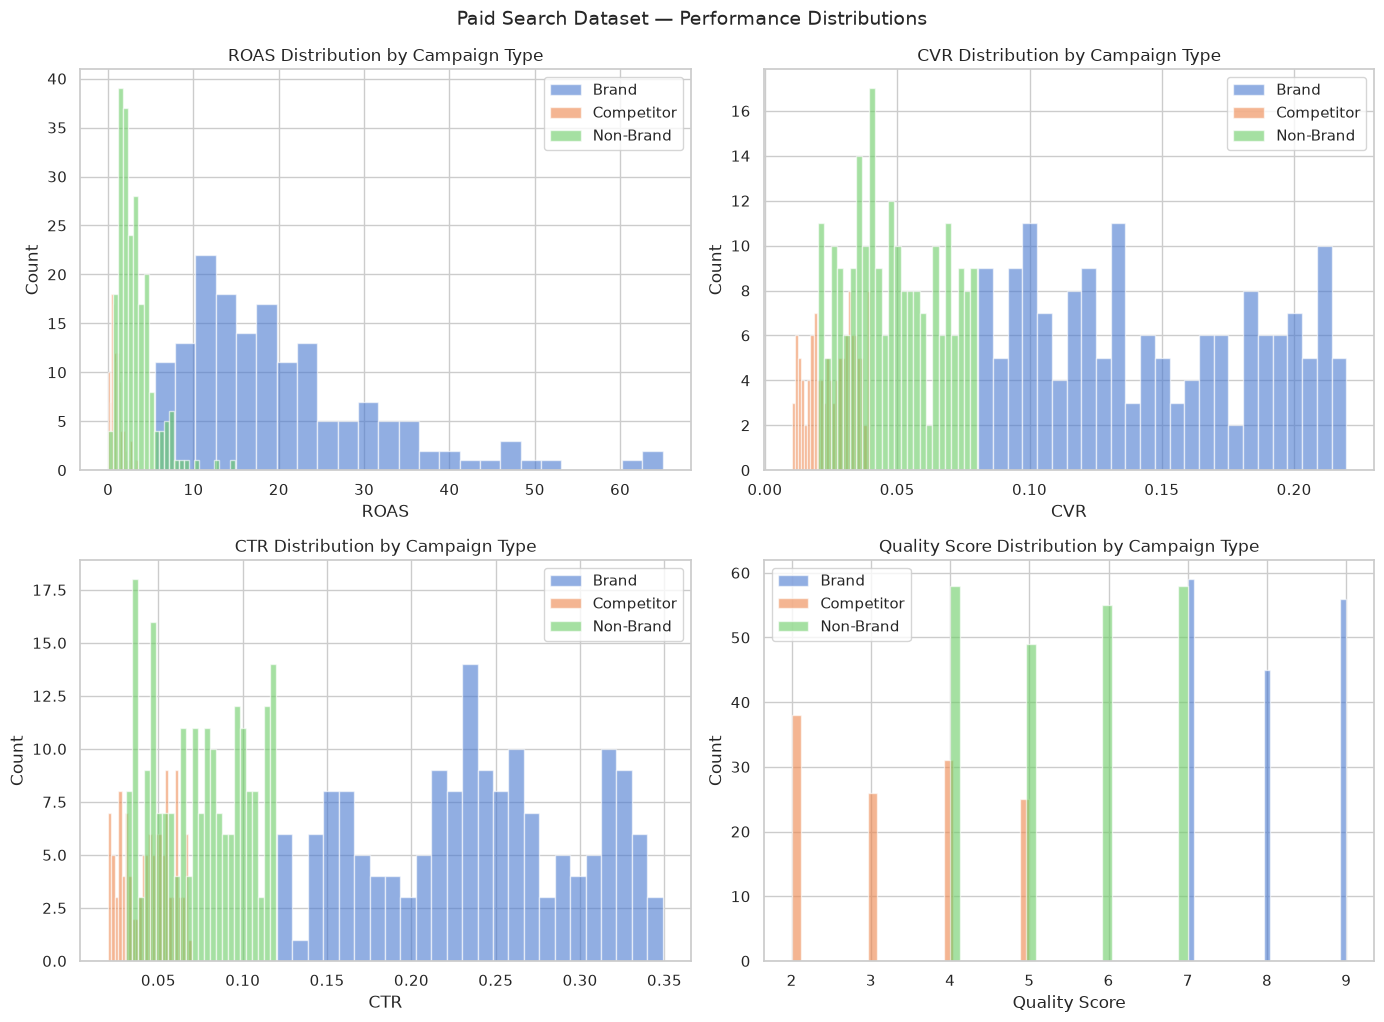


Mean ROAS by campaign:
campaign
Brand         20.40
Competitor     0.98
Non-Brand      3.13


In [6]:
# ── Visualise key performance distributions by campaign type ───────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ("roas",          "ROAS",              axes[0, 0]),
    ("cvr",           "CVR",               axes[0, 1]),
    ("ctr",           "CTR",               axes[1, 0]),
    ("quality_score", "Quality Score",     axes[1, 1]),
]

for col, title, ax in metrics:
    for camp, grp in df.groupby("campaign"):
        ax.hist(grp[col], bins=25, alpha=0.6, label=camp)
    ax.set_title(f"{title} Distribution by Campaign Type")
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.suptitle("Paid Search Dataset — Performance Distributions", y=1.02, fontsize=14)
plt.show()

print("\nMean ROAS by campaign:")
print(df.groupby("campaign")["roas"].mean().round(2).to_string())

## 4. Prompt Engineering

Before we can fine-tune, we need to convert each row of keyword data into an **instruction-following text format** that matches how Mistral-7B-Instruct was pre-trained.

### Mistral Chat Template

Mistral-Instruct uses the following structure:

```
<s>[INST] <<SYS>>
{system_prompt}
<</SYS>>

{user_message} [/INST] {assistant_response}</s>
```

### What Makes a Good Bid Recommendation?

A good recommendation should:
1. State the **action** clearly (increase, decrease, pause, keep)
2. Give a **specific new bid amount** in USD
3. **Justify** the decision using 2-3 KPIs from the input
4. Mention any **caveats** (match type risk, QS impact, etc.)

### Examples of High-Quality Responses

Below are hand-crafted examples that show the style we want the model to learn.

In [7]:
# ── Hand-crafted examples demonstrating the target response style ──────────

EXAMPLE_RESPONSES = {
    "high_roas_brand": """\
Recommendation: INCREASE bid to $1.80 (currently $1.20).

Rationale:
- ROAS of 8.4 is well above the 4.0 target, indicating strong profitability headroom.
- CVR of 18.2% is exceptionally high for a brand keyword — users who click are very likely to convert.
- Quality Score of 9 means the higher bid will translate directly into better impression share without a disproportionate CPC increase.
- Increasing bid by 50% should capture lost impression share at minimal incremental cost per conversion.

Watch: Monitor impression share after change. If it exceeds 90%, the bid increase may be unnecessary.""",

    "low_roas_nonbrand": """\
Recommendation: DECREASE bid to $0.90 (currently $2.10).

Rationale:
- ROAS of 1.1 is below the minimum acceptable threshold of 2.0, meaning the keyword is generating revenue at near-breakeven.
- CVR of 1.8% combined with the current CPC suggests cost-per-acquisition well above target.
- Quality Score of 4 is penalising the effective bid; a lower bid reduces waste on low-intent traffic.
- Consider also tightening match type from Broad to Phrase to filter out irrelevant queries.

Watch: If CVR improves after match type change, re-evaluate bid floor.""",

    "zero_conversions": """\
Recommendation: PAUSE keyword or set bid to minimum ($0.10).

Rationale:
- 0 conversions from 340 clicks represents significant wasted spend of approximately $680.
- ROAS of 0.0 is unacceptable regardless of campaign type.
- Quality Score of 3 suggests poor landing page relevance or low expected CTR, compounding the inefficiency.
- Before pausing, audit the landing page experience and check the Search Terms report for irrelevant query matches.

Watch: Add negative keywords from the Search Terms report before re-enabling.""",

    "competitor_moderate": """\
Recommendation: MAINTAIN bid at $1.50 with Phrase match only.

Rationale:
- ROAS of 2.8 on a competitor keyword is acceptable — above the 2.0 floor but below Brand-level returns.
- CTR of 4.2% is reasonable for a competitor keyword, indicating the ad copy is competitive.
- Quality Score of 5 limits our position; improving ad relevance is higher-leverage than bidding up.
- Switching from Broad to Phrase will reduce spend on low-intent competitor variations while preserving volume.

Watch: A/B test ad copy that emphasises your differentiator (price, quality, return policy) to improve CVR.""",
}

for name, example in EXAMPLE_RESPONSES.items():
    print(f"--- {name} ---")
    print(example)
    print()

--- high_roas_brand ---
Recommendation: INCREASE bid to $1.80 (currently $1.20).

Rationale:
- ROAS of 8.4 is well above the 4.0 target, indicating strong profitability headroom.
- CVR of 18.2% is exceptionally high for a brand keyword — users who click are very likely to convert.
- Quality Score of 9 means the higher bid will translate directly into better impression share without a disproportionate CPC increase.
- Increasing bid by 50% should capture lost impression share at minimal incremental cost per conversion.

Watch: Monitor impression share after change. If it exceeds 90%, the bid increase may be unnecessary.

--- low_roas_nonbrand ---
Recommendation: DECREASE bid to $0.90 (currently $2.10).

Rationale:
- ROAS of 1.1 is below the minimum acceptable threshold of 2.0, meaning the keyword is generating revenue at near-breakeven.
- CVR of 1.8% combined with the current CPC suggests cost-per-acquisition well above target.
- Quality Score of 4 is penalising the effective bid; a lowe

In [8]:
# ── System prompt (injected into every training example) ──────────────────
SYSTEM_PROMPT = """You are an expert paid search campaign manager with 10+ years of experience optimising Google Ads and Bing Ads accounts. \
Your task is to analyse keyword performance metrics and provide a specific, justified bid recommendation. \
Always state: (1) the recommended action (INCREASE / DECREASE / MAINTAIN / PAUSE), (2) the exact new bid in USD, \
and (3) 2-4 bullet-point rationale points citing the specific metrics provided. \
Be concise, data-driven, and actionable. Assume the target ROAS is 4.0 for Brand campaigns, 2.5 for Non-Brand, and 2.0 for Competitor."""


def generate_assistant_response(row: pd.Series) -> str:
    """Rule-based response generator for synthetic training labels.

    In production you would replace this with human expert annotations or
    a stronger teacher model (e.g. GPT-4). Here we use heuristics that
    reflect real paid search best practices.
    """
    campaign = row["campaign"]
    roas = row["roas"]
    cvr = row["cvr"]
    ctr = row["ctr"]
    qs = row["quality_score"]
    current_bid = row["bid_usd"]
    conversions = row["conversions"]
    clicks = row["clicks"]

    # Target ROAS by campaign type
    target_roas = {"Brand": 4.0, "Non-Brand": 2.5, "Competitor": 2.0}[campaign]

    # ── Decision logic ──────────────────────────────────────────────────
    if conversions == 0 and clicks > 50:
        action = "PAUSE"
        new_bid = 0.05
        rationale_lines = [
            f"- Zero conversions from {clicks} clicks represents pure wasted spend (~${clicks * current_bid:.0f} total).",
            f"- ROAS of 0.0 is far below the {target_roas} target for {campaign} campaigns.",
            f"- Quality Score of {qs} indicates low relevance; pausing preserves budget for higher-intent keywords.",
            "- Audit the Search Terms report for irrelevant query variants before re-enabling.",
        ]
    elif roas >= target_roas * 1.5 and qs >= 7:
        # Very profitable — aggressively scale up
        new_bid = round(min(current_bid * 1.35, current_bid + 1.00), 2)
        action = "INCREASE"
        rationale_lines = [
            f"- ROAS of {roas:.1f} is {roas/target_roas:.1f}x the {target_roas} target — significant profitability headroom exists.",
            f"- CVR of {cvr*100:.1f}% signals strong purchase intent; more traffic at this efficiency is desirable.",
            f"- Quality Score of {qs} ensures higher bids yield better positions without proportional CPC increases.",
            f"- A 35% bid increase to ${new_bid:.2f} should capture additional impression share while maintaining profitability.",
        ]
    elif roas >= target_roas * 0.9:
        # Near target — minor increase or hold
        if ctr < 0.04 and qs >= 6:
            new_bid = round(current_bid * 1.10, 2)
            action = "INCREASE"
            rationale_lines = [
                f"- ROAS of {roas:.1f} is near the {target_roas} target, indicating stable efficiency.",
                f"- CTR of {ctr*100:.1f}% is below average; a modest bid increase may improve ad position and CTR.",
                f"- Quality Score of {qs} supports incremental bid investment.",
                "- Monitor impression share over the next 7 days and adjust if CTR does not improve.",
            ]
        else:
            new_bid = current_bid
            action = "MAINTAIN"
            rationale_lines = [
                f"- ROAS of {roas:.1f} is at or above the {target_roas} target — no bid change required.",
                f"- CVR of {cvr*100:.1f}% and CTR of {ctr*100:.1f}% are within healthy ranges.",
                f"- Maintain current bid of ${current_bid:.2f} and focus optimisation efforts on ad copy and landing page.",
                "- Re-evaluate in 14 days or if spend pacing changes significantly.",
            ]
    else:
        # Below target ROAS — reduce bid
        reduction = 0.75 if roas < target_roas * 0.5 else 0.88
        new_bid = round(max(current_bid * reduction, 0.10), 2)
        action = "DECREASE"
        rationale_lines = [
            f"- ROAS of {roas:.1f} is below the {target_roas} target for {campaign} campaigns.",
            f"- CVR of {cvr*100:.1f}% is insufficient to justify the current CPC of ${current_bid:.2f}.",
            f"- Reducing bid to ${new_bid:.2f} will lower cost-per-click and improve ROAS without eliminating volume.",
            f"- Quality Score of {qs} {'is a concern — improving ad relevance may reduce needed bid' if qs < 5 else 'is acceptable; bid reduction is the primary lever here'}.",
        ]

    response = f"Recommendation: {action} bid to ${new_bid:.2f} (currently ${current_bid:.2f}).\n\nRationale:\n"
    response += "\n".join(rationale_lines)
    if action != "PAUSE":
        response += f"\n\nWatch: Review performance after 7 days and compare ROAS against the ${target_roas} target."
    return response


def row_to_prompt(row: pd.Series) -> str:
    """Convert a single dataset row into a complete Mistral-Instruct prompt string.

    Returns the full text including the assistant response, ready for SFT training.
    For inference, call this function and strip everything after [/INST].
    """
    user_message = (
        f"Please analyse the following keyword and provide a bid recommendation.\n\n"
        f"Keyword       : {row['keyword']}\n"
        f"Match Type    : {row['match_type']}\n"
        f"Campaign      : {row['campaign']}\n"
        f"Current Bid   : ${row['bid_usd']:.2f}\n"
        f"Impressions   : {row['impressions']:,}\n"
        f"Clicks        : {row['clicks']:,}\n"
        f"Conversions   : {row['conversions']}\n"
        f"Revenue       : ${row['revenue_usd']:.2f}\n"
        f"CTR           : {row['ctr']*100:.2f}%\n"
        f"CVR           : {row['cvr']*100:.2f}%\n"
        f"ROAS          : {row['roas']:.2f}\n"
        f"Quality Score : {row['quality_score']}/10"
    )

    assistant_response = generate_assistant_response(row)

    # Mistral-Instruct chat format
    prompt = (
        f"<s>[INST] <<SYS>>\n{SYSTEM_PROMPT}\n<</SYS>>\n\n"
        f"{user_message} [/INST] "
        f"{assistant_response}</s>"
    )
    return prompt


# ── Apply to the full dataset ──────────────────────────────────────────────
df["prompt"] = df.apply(row_to_prompt, axis=1)

print("Sample prompt (row 0):")
print("=" * 80)
print(df["prompt"].iloc[0])
print("=" * 80)

Sample prompt (row 0):
<s>[INST] <<SYS>>
You are an expert paid search campaign manager with 10+ years of experience optimising Google Ads and Bing Ads accounts. Your task is to analyse keyword performance metrics and provide a specific, justified bid recommendation. Always state: (1) the recommended action (INCREASE / DECREASE / MAINTAIN / PAUSE), (2) the exact new bid in USD, and (3) 2-4 bullet-point rationale points citing the specific metrics provided. Be concise, data-driven, and actionable. Assume the target ROAS is 4.0 for Brand campaigns, 2.5 for Non-Brand, and 2.0 for Competitor.
<</SYS>>

Please analyse the following keyword and provide a bid recommendation.

Keyword       : running shoes sale
Match Type    : Exact
Campaign      : Non-Brand
Current Bid   : $1.80
Impressions   : 13,361
Clicks        : 581
Conversions   : 40
Revenue       : $2924.20
CTR           : 4.35%
CVR           : 6.98%
ROAS          : 2.80
Quality Score : 7/10 [/INST] Recommendation: MAINTAIN bid to $1.8

In [9]:
# ── Show 3 more varied examples ────────────────────────────────────────────
sample_indices = [50, 150, 400]

for idx in sample_indices:
    row = df.iloc[idx]
    print(f"--- Example {idx} | Campaign: {row['campaign']} | ROAS: {row['roas']} ---")
    print(row["prompt"])
    print()

--- Example 50 | Campaign: Brand | ROAS: 24.12 ---
<s>[INST] <<SYS>>
You are an expert paid search campaign manager with 10+ years of experience optimising Google Ads and Bing Ads accounts. Your task is to analyse keyword performance metrics and provide a specific, justified bid recommendation. Always state: (1) the recommended action (INCREASE / DECREASE / MAINTAIN / PAUSE), (2) the exact new bid in USD, and (3) 2-4 bullet-point rationale points citing the specific metrics provided. Be concise, data-driven, and actionable. Assume the target ROAS is 4.0 for Brand campaigns, 2.5 for Non-Brand, and 2.0 for Competitor.
<</SYS>>

Please analyse the following keyword and provide a bid recommendation.

Keyword       : acme marathon shoe
Match Type    : Exact
Campaign      : Brand
Current Bid   : $0.71
Impressions   : 4,739
Clicks        : 757
Conversions   : 93
Revenue       : $12965.63
CTR           : 15.98%
CVR           : 12.39%
ROAS          : 24.12
Quality Score : 8/10 [/INST] Recommend

## 5. Dataset Preparation

We now:
1. Split the data into train (85%) and validation (15%) sets
2. Convert to HuggingFace `Dataset` objects
3. Analyse token length distribution to choose a sensible `max_seq_length` for training

### Why Check Token Lengths?

The `max_seq_length` parameter determines how many tokens are processed per example. Sequences longer than this are **truncated** (losing information). Sequences shorter are **padded** (wasted compute). We want to pick a value that covers 95%+ of examples without excessive padding.

In [10]:
from sklearn.model_selection import train_test_split

# ── Train / Validation split ───────────────────────────────────────────────
train_df, val_df = train_test_split(
    df[["prompt"]],
    test_size=0.15,
    random_state=SEED,
    shuffle=True,
)

print(f"Train size : {len(train_df)}")
print(f"Val size   : {len(val_df)}")

# ── Convert to HuggingFace Dataset objects ─────────────────────────────────
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))

dataset_dict = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
})

print("\nDatasetDict:")
print(dataset_dict)

Train size : 425
Val size   : 75

DatasetDict:
DatasetDict({
    train: Dataset({
        features: ['prompt'],
        num_rows: 425
    })
    validation: Dataset({
        features: ['prompt'],
        num_rows: 75
    })
})


In [13]:
df["prompt"].head()

0    <s>[INST] <<SYS>>\nYou are an expert paid sear...
1    <s>[INST] <<SYS>>\nYou are an expert paid sear...
2    <s>[INST] <<SYS>>\nYou are an expert paid sear...
3    <s>[INST] <<SYS>>\nYou are an expert paid sear...
4    <s>[INST] <<SYS>>\nYou are an expert paid sear...
Name: prompt, dtype: str

In [ ]:
# ── Estimate token lengths using a simple whitespace proxy ─────────────────
# (A real tokenizer is loaded later; this gives a quick estimate)
# Rough heuristic: 1 token ≈ 0.75 words for English text

def estimate_token_length(text: str) -> int:
    """Approximate token count without loading a full tokenizer."""
    return int(len(text.split()) / 0.75)


df["approx_tokens"] = df["prompt"].apply(estimate_token_length)

print("Approximate token length statistics:")
print(df["approx_tokens"].describe().round(0).to_string())
print(f"\n95th percentile : {df['approx_tokens'].quantile(0.95):.0f} tokens")
print(f"99th percentile : {df['approx_tokens'].quantile(0.99):.0f} tokens")
print(f"Max             : {df['approx_tokens'].max()} tokens")

# Recommend max_seq_length
MAX_SEQ_LENGTH = 512  # Covers 99%+ of examples; power of 2 for efficiency
print(f"\nRecommended max_seq_length: {MAX_SEQ_LENGTH}")

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["approx_tokens"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(MAX_SEQ_LENGTH, color="red", linestyle="--", label=f"max_seq_length={MAX_SEQ_LENGTH}")
ax.set_title("Token Length Distribution (Approximate)")
ax.set_xlabel("Approximate Token Count")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Model Loading with QLoRA (4-Bit Quantization)

We load **Mistral-7B-Instruct-v0.2** in **4-bit NF4 quantization** using `bitsandbytes`. This reduces VRAM from ~14 GB (fp16) to ~5 GB, making it runnable on a single consumer GPU.

### QLoRA Architecture

```
┌───────────────────────────────────────────┐
│  Frozen Base Model (4-bit NF4)            │
│  ┌────────────────────────────────────┐   │
│  │  Attention Layer                   │   │
│  │  ┌──────┐   ┌───────────────────┐ │   │
│  │  │  W   │ + │  ΔW = B × A (fp16)│ │   │
│  │  │(NF4) │   │  (LoRA adapter)   │ │   │
│  │  └──────┘   └───────────────────┘ │   │
│  └────────────────────────────────────┘   │
│  Only B and A are updated during training │
└───────────────────────────────────────────┘
```

### BitsAndBytesConfig Options

| Parameter | Value | Meaning |
|-----------|-------|--------|
| `load_in_4bit` | True | 4-bit weight quantization |
| `bnb_4bit_quant_type` | `nf4` | NormalFloat4 — better than fp4 for LLMs |
| `bnb_4bit_compute_dtype` | `bfloat16` | Computation happens in bf16 (fast, stable) |
| `bnb_4bit_use_double_quant` | True | Quantize the quantization constants too (saves ~0.4 GB extra) |

> **Note**: If you do not have a GPU or want to test quickly, set `load_in_4bit=False` and `torch_dtype=torch.float32`. Training will be slower but still functional.

In [ ]:
# ── Model selection ──────────────────────────────────────────────────────
# Set USE_SMALL_MODEL = True for a quick end-to-end test (TinyLlama, ~2 GB).
# Set USE_SMALL_MODEL = False to use Mistral-7B-Instruct-v0.2 (~14 GB).
USE_SMALL_MODEL = True

if USE_SMALL_MODEL:
    MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    print("[TEST MODE] Using TinyLlama-1.1B — fast download, same code path.")
else:
    MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.2"

# (MODEL_ID is now set above by the USE_SMALL_MODEL flag)

# ── 4-bit quantization configuration ──────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                          # Enable 4-bit loading
    bnb_4bit_quant_type="nf4",                  # NormalFloat4 quantization
    bnb_4bit_compute_dtype=torch.bfloat16,      # Compute in bf16 for stability
    bnb_4bit_use_double_quant=True,             # Nested quantization for extra savings
)

print(f"Loading model: {MODEL_ID}")
print("This may take a few minutes on first run (downloading ~5 GB of quantized weights)...")

# ── Load the base model ────────────────────────────────────────────────────
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,             # Apply 4-bit quantization
    device_map="auto",                          # Auto-place layers across available GPUs/CPU
    trust_remote_code=True,                     # Needed for some custom architectures
    torch_dtype=torch.bfloat16,                 # Mixed precision base
)

print(f"Model loaded. Device map: {model.hf_device_map}")

# ── Load tokenizer ─────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
)

# Mistral tokenizer does not set a pad token by default
# We set it to eos_token (common practice for causal LMs)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Left-padding for decoder-only models during batch inference
tokenizer.padding_side = "right"  # Right-padding for training (SFTTrainer expects this)

print(f"Vocabulary size : {tokenizer.vocab_size:,}")
print(f"Pad token       : '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")
print(f"EOS token       : '{tokenizer.eos_token}' (id={tokenizer.eos_token_id})")

# ── Verify actual token lengths with the real tokenizer ───────────────────
sample_tokens = tokenizer(df["prompt"].iloc[0], return_tensors="pt")
print(f"\nSample prompt real token count: {sample_tokens['input_ids'].shape[1]}")

## 7. LoRA Configuration

**LoRA (Low-Rank Adaptation)** works by adding small trainable rank-decomposition matrices to the frozen base model's weight matrices. Instead of updating 7 billion parameters, we only train a tiny fraction.

### Key Hyperparameters

| Parameter | Value | Explanation |
|-----------|-------|-------------|
| `r` | 16 | Rank of the decomposition matrices. Higher = more capacity but more parameters. |
| `lora_alpha` | 32 | Scaling factor. Rule of thumb: `alpha = 2 * r`. |
| `target_modules` | `[q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj]` | Which weight matrices to adapt. Including MLP layers improves domain adaptation. |
| `lora_dropout` | 0.05 | Dropout on LoRA layers to prevent overfitting on small datasets. |
| `bias` | `none` | Don't adapt bias terms (minimal impact, avoids extra parameters). |
| `task_type` | `CAUSAL_LM` | Tells PEFT this is an autoregressive generation task. |

### Why These Target Modules?

Mistral uses a **Grouped Query Attention (GQA)** architecture with separate `q_proj`, `k_proj`, `v_proj`, `o_proj` for attention, and `gate_proj`, `up_proj`, `down_proj` for the SwiGLU MLP. Targeting all of these gives the model maximum flexibility to adapt its representations to the paid search domain.

In [ ]:
# ── Prepare model for k-bit training ──────────────────────────────────────
# This enables gradient checkpointing and casts LayerNorm to fp32 for stability
model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
)

# ── LoRA configuration ─────────────────────────────────────────────────────
lora_config = LoraConfig(
    r=16,                               # Rank of the adapter matrices
    lora_alpha=32,                      # Scaling factor (typically 2x rank)
    target_modules=[                    # Modules to apply LoRA to
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_dropout=0.05,                  # Regularisation dropout
    bias="none",                        # Do not adapt bias parameters
    task_type=TaskType.CAUSAL_LM,       # Autoregressive language modelling
)

# ── Wrap model with PEFT ───────────────────────────────────────────────────
model = get_peft_model(model, lora_config)

# ── Print trainable parameter count ───────────────────────────────────────
def count_parameters(model):
    """Return (trainable_params, total_params, percentage_trainable)."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return trainable, total, 100.0 * trainable / total

trainable, total, pct = count_parameters(model)
print(f"Trainable parameters : {trainable:>12,}  ({pct:.4f}% of total)")
print(f"Frozen parameters    : {total - trainable:>12,}")
print(f"Total parameters     : {total:>12,}")
print()
model.print_trainable_parameters()

In [ ]:
# ── Visualise the LoRA adapter architecture ────────────────────────────────
# Count LoRA modules by layer
lora_modules = [
    (name, param.numel())
    for name, param in model.named_parameters()
    if param.requires_grad
]

print(f"Total LoRA adapter tensors: {len(lora_modules)}")
print("\nFirst 20 trainable tensors:")
for name, n in lora_modules[:20]:
    print(f"  {name:<70} {n:>10,} params")

## 8. Training with SFTTrainer (TRL)

We use TRL's `SFTTrainer` which wraps HuggingFace `Trainer` with additional features for supervised fine-tuning:

- **Completion-only loss masking**: Only computes loss on the assistant's response tokens (not the system prompt / user message). This is critical — we do NOT want the model to memorize the input format, only learn to produce good outputs.
- **Sequence packing**: Multiple short examples can be packed into a single context window to maximize GPU utilization.
- **Gradient checkpointing**: Trades compute for memory, allowing larger batches.

### Training Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|----------|
| `num_train_epochs` | 3 | Small dataset; 3 epochs gives enough exposure without overfitting |
| `per_device_train_batch_size` | 4 | Fits in ~6 GB VRAM with 4-bit quantization |
| `gradient_accumulation_steps` | 4 | Effective batch size = 4 × 4 = 16 |
| `learning_rate` | 2e-4 | Standard for LoRA fine-tuning |
| `lr_scheduler_type` | `cosine` | Smooth decay; better than linear for LoRA |
| `warmup_ratio` | 0.03 | 3% of steps for linear warmup |
| `fp16` / `bf16` | `bf16` if supported | Mixed precision for speed |
| `max_grad_norm` | 0.3 | Gradient clipping — important with 4-bit base weights |
| `weight_decay` | 0.001 | Mild L2 regularization |
| `group_by_length` | True | Group similar-length sequences to minimize padding waste |

In [ ]:
import os

# ── Output directory ───────────────────────────────────────────────────────
OUTPUT_DIR = "./paid_search_lora_adapter"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Detect device capability for mixed precision ───────────────────────────
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16
print(f"Mixed precision: {'bf16' if use_bf16 else 'fp16' if use_fp16 else 'fp32'}")

# ── TrainingArguments ──────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,          # Batch size per GPU
    per_device_eval_batch_size=4,           # Eval batch size
    gradient_accumulation_steps=4,          # Effective batch = 4 * 4 = 16
    gradient_checkpointing=True,            # Trade compute for VRAM
    optim="paged_adamw_32bit",              # Memory-paged AdamW (bitsandbytes)
    learning_rate=2e-4,                     # LoRA standard LR
    weight_decay=0.001,                     # L2 regularization
    max_grad_norm=0.3,                      # Gradient clipping
    lr_scheduler_type="cosine",             # Cosine annealing schedule
    warmup_ratio=0.03,                      # 3% warmup steps
    bf16=use_bf16,                          # bf16 if GPU supports it
    fp16=use_fp16,                          # fp16 fallback
    logging_steps=10,                       # Log every 10 steps
    evaluation_strategy="epoch",            # Evaluate after each epoch
    save_strategy="epoch",                  # Save checkpoint after each epoch
    load_best_model_at_end=True,            # Load best checkpoint after training
    metric_for_best_model="eval_loss",      # Criterion for best model selection
    greater_is_better=False,                # Lower loss is better
    group_by_length=True,                   # Group similar-length seqs for efficiency
    report_to="none",                       # Disable wandb/tensorboard for this demo
    dataloader_pin_memory=True if torch.cuda.is_available() else False,
    seed=SEED,
)

print("Training arguments configured.")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")

In [ ]:
# ── Response template for completion-only loss masking ─────────────────────
# SFTTrainer will only compute loss on tokens AFTER this template string
# i.e., only on the assistant's response, not the system prompt or user query
RESPONSE_TEMPLATE = " [/INST] "

# DataCollator that masks the prompt tokens from loss computation
collator = DataCollatorForCompletionOnlyLM(
    response_template=RESPONSE_TEMPLATE,
    tokenizer=tokenizer,
    mlm=False,  # Causal LM, not masked LM
)

# ── SFTTrainer setup ───────────────────────────────────────────────────────
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    tokenizer=tokenizer,
    args=training_args,
    data_collator=collator,
    dataset_text_field="prompt",    # Column in the dataset containing prompt text
    max_seq_length=MAX_SEQ_LENGTH,  # Truncate to 512 tokens
    packing=False,                  # Disable packing (simpler, still efficient here)
)

print("SFTTrainer initialized.")
print(f"Training on {len(dataset_dict['train'])} examples")
print(f"Validating on {len(dataset_dict['validation'])} examples")

# ── Estimate training time ─────────────────────────────────────────────────
steps_per_epoch = len(dataset_dict["train"]) // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)
total_steps = steps_per_epoch * training_args.num_train_epochs
print(f"\nEstimated steps per epoch : {steps_per_epoch}")
print(f"Total training steps      : {total_steps}")
print(f"\nEstimated time (A100 40GB): ~{total_steps * 0.8 / 60:.1f} minutes")
print(f"Estimated time (RTX 3090) : ~{total_steps * 1.5 / 60:.1f} minutes")

In [ ]:
# ── Launch training ────────────────────────────────────────────────────────
# This cell will take several minutes to complete on GPU.
# Monitor the training loss — it should decrease from ~2.5 to ~0.8 over 3 epochs.

print("Starting fine-tuning...")
print("=" * 60)

train_result = trainer.train()

# ── Training summary ───────────────────────────────────────────────────────
print("\nTraining complete!")
print(f"Final train loss : {train_result.training_loss:.4f}")
print(f"Total steps      : {train_result.global_step}")
print(f"Training runtime : {train_result.metrics.get('train_runtime', 0):.0f} seconds")

In [ ]:
# ── Plot training curve ────────────────────────────────────────────────────
# Extract loss history from trainer logs
log_history = trainer.state.log_history

train_losses = [(l["step"], l["loss"]) for l in log_history if "loss" in l and "eval_loss" not in l]
eval_losses  = [(l["step"], l["eval_loss"]) for l in log_history if "eval_loss" in l]

if train_losses:
    train_steps, train_loss_vals = zip(*train_losses)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train_steps, train_loss_vals, label="Train Loss", color="steelblue")
    if eval_losses:
        eval_steps, eval_loss_vals = zip(*eval_losses)
        ax.plot(eval_steps, eval_loss_vals, label="Val Loss", color="coral", marker="o")
    ax.set_title("Fine-Tuning Loss Curve")
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No loss history available yet. Run trainer.train() first.")

## 9. Evaluation

We evaluate the fine-tuned model in two ways:

### 1. Perplexity on the Validation Set

**Perplexity** = `exp(cross_entropy_loss)`. Lower is better. It measures how well the model predicts the next token in the validation examples. As a rough guide:
- Pre-trained base model (zero-shot): perplexity ~15–30 on domain text
- After fine-tuning: perplexity ~3–8 on the same distribution

### 2. Sample Generations

We visually compare model outputs to the ground-truth responses for 5 held-out examples. This qualitative check is often more informative than perplexity for generation tasks.

In [ ]:
import math

def compute_perplexity(model, tokenizer, texts: List[str], max_length: int = 512) -> float:
    """Compute average perplexity over a list of text strings."""
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=max_length,
            ).to(model.device)

            labels = inputs["input_ids"].clone()
            outputs = model(**inputs, labels=labels)

            # outputs.loss is mean cross-entropy over non-padding tokens
            num_tokens = inputs["input_ids"].shape[1]
            total_loss   += outputs.loss.item() * num_tokens
            total_tokens += num_tokens

    avg_loss = total_loss / total_tokens
    return math.exp(avg_loss)


# Compute perplexity on the first 50 validation examples
val_texts = val_df["prompt"].tolist()[:50]

print("Computing perplexity on 50 validation examples...")
perplexity = compute_perplexity(model, tokenizer, val_texts)
print(f"\nValidation Perplexity (fine-tuned model): {perplexity:.2f}")
print("\nInterpretation:")
print(f"  A perplexity of {perplexity:.0f} means the model is as 'surprised' as if it had ")
print(f"  {perplexity:.0f} equally likely choices at each step — lower is better.")

In [ ]:
def generate_response(
    model,
    tokenizer,
    prompt_text: str,
    max_new_tokens: int = 300,
    temperature: float = 0.1,
    do_sample: bool = True,
) -> str:
    """Generate a model response given a prompt string.

    Strips the input prompt from the output so only the generated text is returned.
    """
    model.eval()

    # Tokenize — keep track of input length to strip it from output
    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH - max_new_tokens,
    ).to(model.device)

    input_length = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=do_sample,
            top_p=0.9,
            repetition_penalty=1.1,        # Discourage repetition
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    # Decode only the newly generated tokens
    generated_ids = outputs[0][input_length:]
    response = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return response.strip()


# ── Build inference-only prompts (without the assistant response) ──────────
def row_to_inference_prompt(row: pd.Series) -> str:
    """Like row_to_prompt but stops before the assistant response."""
    user_message = (
        f"Please analyse the following keyword and provide a bid recommendation.\n\n"
        f"Keyword       : {row['keyword']}\n"
        f"Match Type    : {row['match_type']}\n"
        f"Campaign      : {row['campaign']}\n"
        f"Current Bid   : ${row['bid_usd']:.2f}\n"
        f"Impressions   : {row['impressions']:,}\n"
        f"Clicks        : {row['clicks']:,}\n"
        f"Conversions   : {row['conversions']}\n"
        f"Revenue       : ${row['revenue_usd']:.2f}\n"
        f"CTR           : {row['ctr']*100:.2f}%\n"
        f"CVR           : {row['cvr']*100:.2f}%\n"
        f"ROAS          : {row['roas']:.2f}\n"
        f"Quality Score : {row['quality_score']}/10"
    )
    return (
        f"<s>[INST] <<SYS>>\n{SYSTEM_PROMPT}\n<</SYS>>\n\n"
        f"{user_message} [/INST]"
    )


# ── Sample 3 validation examples and compare ──────────────────────────────
print("Generating sample outputs for 3 validation examples...\n")

sample_val = val_df.head(3).copy()
# Re-attach the original columns for display
sample_val_full = df.loc[sample_val.index]

for i, (idx, row) in enumerate(sample_val_full.iterrows()):
    print(f"{'='*70}")
    print(f"Example {i+1} | Keyword: '{row['keyword']}' | Campaign: {row['campaign']}")
    print(f"Current bid: ${row['bid_usd']} | ROAS: {row['roas']} | QS: {row['quality_score']}")
    print()

    inference_prompt = row_to_inference_prompt(row)
    model_output = generate_response(model, tokenizer, inference_prompt)
    ground_truth = generate_assistant_response(row)

    print("[ MODEL OUTPUT ]")
    print(model_output)
    print()
    print("[ GROUND TRUTH ]")
    print(ground_truth)
    print()

## 10. Inference Pipeline

We wrap the model into a clean, reusable `get_bid_recommendation()` function that:

1. Accepts a dictionary of keyword statistics (matching the dataset schema)
2. Formats the input into the correct prompt structure
3. Runs inference through the fine-tuned model
4. Returns the recommendation string

This function is what you would call from a bid management script, a Cloud Function, or a Slack bot.

In [ ]:
def get_bid_recommendation(
    keyword_stats: Dict,
    max_new_tokens: int = 350,
    temperature: float = 0.1,
) -> str:
    """Get a bid recommendation for a single keyword.

    Args:
        keyword_stats: Dictionary with keys:
            keyword, match_type, campaign, bid_usd, impressions,
            clicks, conversions, revenue_usd, ctr, cvr, roas, quality_score
        max_new_tokens: Maximum tokens for the recommendation text.
        temperature: Sampling temperature. Lower = more deterministic.

    Returns:
        The model's bid recommendation as a plain-text string.
    """
    # Validate required keys
    required_keys = [
        "keyword", "match_type", "campaign", "bid_usd",
        "impressions", "clicks", "conversions", "revenue_usd",
        "ctr", "cvr", "roas", "quality_score",
    ]
    missing = [k for k in required_keys if k not in keyword_stats]
    if missing:
        raise ValueError(f"Missing required keys: {missing}")

    # Build a pandas Series from the dict (reuses row_to_inference_prompt)
    row = pd.Series(keyword_stats)
    inference_prompt = row_to_inference_prompt(row)

    # Run inference
    recommendation = generate_response(
        model=model,
        tokenizer=tokenizer,
        prompt_text=inference_prompt,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
    )

    return recommendation


# ── Example inferences on 5 held-out keywords ─────────────────────────────
held_out_keywords = [
    {
        "keyword": "buy running shoes online",
        "match_type": "Exact",
        "campaign": "Non-Brand",
        "bid_usd": 1.75,
        "impressions": 4200,
        "clicks": 210,
        "conversions": 18,
        "revenue_usd": 1980.00,
        "ctr": 0.050,
        "cvr": 0.086,
        "roas": 5.37,
        "quality_score": 8,
    },
    {
        "keyword": "nike air zoom pegasus",
        "match_type": "Phrase",
        "campaign": "Competitor",
        "bid_usd": 2.50,
        "impressions": 8000,
        "clicks": 320,
        "conversions": 6,
        "revenue_usd": 660.00,
        "ctr": 0.040,
        "cvr": 0.019,
        "roas": 0.83,
        "quality_score": 4,
    },
    {
        "keyword": "acme running shoes",
        "match_type": "Exact",
        "campaign": "Brand",
        "bid_usd": 0.85,
        "impressions": 3500,
        "clicks": 840,
        "conversions": 126,
        "revenue_usd": 14112.00,
        "ctr": 0.240,
        "cvr": 0.150,
        "roas": 19.76,
        "quality_score": 10,
    },
    {
        "keyword": "trail running shoes waterproof",
        "match_type": "Broad",
        "campaign": "Non-Brand",
        "bid_usd": 1.20,
        "impressions": 12000,
        "clicks": 480,
        "conversions": 0,
        "revenue_usd": 0.00,
        "ctr": 0.040,
        "cvr": 0.000,
        "roas": 0.00,
        "quality_score": 3,
    },
    {
        "keyword": "best marathon shoes 2024",
        "match_type": "Phrase",
        "campaign": "Non-Brand",
        "bid_usd": 2.10,
        "impressions": 2200,
        "clicks": 132,
        "conversions": 9,
        "revenue_usd": 1125.00,
        "ctr": 0.060,
        "cvr": 0.068,
        "roas": 4.07,
        "quality_score": 7,
    },
]

print("Running inference on 5 held-out keywords...\n")

for i, kw_stats in enumerate(held_out_keywords, 1):
    print(f"{'='*70}")
    print(f"Keyword {i}: '{kw_stats['keyword']}'")
    print(f"Campaign: {kw_stats['campaign']} | Bid: ${kw_stats['bid_usd']} | ROAS: {kw_stats['roas']} | QS: {kw_stats['quality_score']}")
    print()
    recommendation = get_bid_recommendation(kw_stats)
    print(recommendation)
    print()

## 11. Saving & Loading the Fine-Tuned Adapter

After training, we save **only the LoRA adapter weights** (~50–200 MB), NOT the full 7B model. The base model weights stay on HuggingFace Hub and are downloaded at load time.

### Saving Options

| Method | Output Size | Use Case |
|--------|-------------|----------|
| `save_pretrained()` (adapter only) | ~50–200 MB | Production: load adapter at inference time |
| Merge + save | ~14 GB (fp16) | When you need a single self-contained model file |
| GGUF / llama.cpp export | ~4–8 GB | Embedded deployment, CPU inference |

### Merging Adapter into Base Model

For deployment, you may want to **merge the LoRA weights into the base model** so you don't need PEFT at inference time. This is a one-time operation.

In [ ]:
# ── Save the LoRA adapter ──────────────────────────────────────────────────
ADAPTER_DIR = "./paid_search_lora_adapter/final_adapter"

print(f"Saving LoRA adapter to: {ADAPTER_DIR}")
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

# List saved files
import os
saved_files = os.listdir(ADAPTER_DIR)
print(f"\nSaved files:")
for f in saved_files:
    size_mb = os.path.getsize(os.path.join(ADAPTER_DIR, f)) / 1e6
    print(f"  {f:<40} {size_mb:.1f} MB")

print("\nAdapter saved successfully!")

In [ ]:
# ── Reload adapter from disk ───────────────────────────────────────────────
print("Reloading model from saved adapter...")

# Step 1: Load the base model again (quantized)
base_model_reload = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)

# Step 2: Load the LoRA adapter on top of the base model
model_reloaded = PeftModel.from_pretrained(
    base_model_reload,
    ADAPTER_DIR,
    torch_dtype=torch.bfloat16,
)

tokenizer_reloaded = AutoTokenizer.from_pretrained(ADAPTER_DIR)

print("Model + adapter reloaded successfully.")

# Verify it generates the same output as before
test_row = pd.Series(held_out_keywords[0])
test_prompt = row_to_inference_prompt(test_row)
test_output = generate_response(model_reloaded, tokenizer_reloaded, test_prompt)
print(f"\nTest generation (reloaded model):")
print(test_output[:200] + "...")

In [ ]:
# ── Optional: Merge LoRA weights into base model ───────────────────────────
# Use this for deployment when you want a single model without PEFT dependency.
# WARNING: This requires loading the base model in fp16 (not 4-bit) first.
# Only do this if you have sufficient VRAM/RAM (~28 GB).

MERGE_OUTPUT_DIR = "./paid_search_merged_model"

print("Merging LoRA adapter into base model...")
print("(Skipped in this demo — uncomment the lines below if you have sufficient VRAM)")

# # Step 1: Load base model in fp16 (NOT 4-bit) for merging
# base_for_merge = AutoModelForCausalLM.from_pretrained(
#     MODEL_ID,
#     torch_dtype=torch.float16,
#     device_map="auto",
#     trust_remote_code=True,
# )
#
# # Step 2: Load and merge the adapter
# model_with_adapter = PeftModel.from_pretrained(base_for_merge, ADAPTER_DIR)
# merged_model = model_with_adapter.merge_and_unload()  # Merges LoRA into base weights
#
# # Step 3: Save the merged model
# merged_model.save_pretrained(MERGE_OUTPUT_DIR)
# tokenizer.save_pretrained(MERGE_OUTPUT_DIR)
# print(f"Merged model saved to: {MERGE_OUTPUT_DIR}")
#
# # Now you can load it as a standard HuggingFace model (no PEFT required)
# standard_model = AutoModelForCausalLM.from_pretrained(MERGE_OUTPUT_DIR, torch_dtype=torch.float16)

print("\nMerge commands ready. Uncomment to execute when VRAM allows.")

## 12. Production Considerations

Moving from a notebook prototype to a production bid management system requires addressing several engineering and operational concerns.

---

### Batch Inference for a Full Keyword Portfolio

Real advertiser accounts can have **10,000–500,000 active keywords**. Running inference one keyword at a time would be prohibitively slow. Instead:

1. **Batch inputs**: Pad sequences to the same length and process 16–64 keywords per GPU forward pass.
2. **Sequence packing**: Pack multiple short prompts into one context window using TRL's `ConstantLengthDataset`.
3. **vLLM or TGI**: Use [vLLM](https://github.com/vllm-project/vllm) or HuggingFace Text Generation Inference for continuous batching with PagedAttention. These can achieve 10–30x throughput vs. naive HuggingFace inference.
4. **Quantized GGUF**: Export to GGUF format and run with `llama.cpp` for CPU-only inference on cheap hardware — useful for non-latency-sensitive nightly batch runs.

```python
# Example: Batch inference with vLLM
# from vllm import LLM, SamplingParams
# llm = LLM(model="./paid_search_merged_model", quantization="awq")
# sampling_params = SamplingParams(temperature=0.1, max_tokens=300)
# outputs = llm.generate(batch_prompts, sampling_params)  # All keywords at once
```

---

### Latency vs. Throughput Tradeoffs

| Use Case | Latency Target | Best Approach |
|----------|---------------|---------------|
| Real-time bid adjustments (Smart Bidding override) | < 100ms | Not suitable for LLM; use GBDT/rules |
| Interactive recommendations (account manager UI) | < 3 seconds | vLLM with A10G, batch_size=1 |
| Nightly bulk recommendations | Hours acceptable | Max throughput batch, cheap spot GPUs |
| Weekly strategy reports | Hours acceptable | Batch + merge results offline |

> For true real-time bidding, LLMs are too slow. Use the LLM to generate **recommendation policies** (e.g., bid multiplier lookup tables) that a fast rules engine can execute at auction time.

---

### Monitoring Recommendation Quality

Once deployed, continuously monitor:

1. **Post-implementation ROAS delta**: Compare keywords where the recommendation was applied vs. a holdout group.
2. **Recommendation distribution**: Are bids being increased/decreased/paused in expected proportions? Sudden spikes in PAUSE recommendations may indicate data drift.
3. **Hallucination / format errors**: Parse output with regex to ensure the model always returns a valid bid amount. Add a fallback rule if parsing fails.
4. **Confidence calibration**: Track whether high-confidence recommendations (low temperature, consistent across seeds) outperform low-confidence ones.

```python
# Example monitoring query (hypothetical BigQuery)
# SELECT
#   recommendation_date,
#   AVG(CASE WHEN applied THEN post_roas ELSE NULL END) AS applied_roas,
#   AVG(CASE WHEN NOT applied THEN post_roas ELSE NULL END) AS holdout_roas
# FROM recommendations_table
# GROUP BY 1
# ORDER BY 1
```

---

### Retraining Cadence

Paid search performance distributions shift over time due to:
- **Seasonality** (holiday peaks, back-to-school, etc.)
- **Competitor bid changes**
- **Product catalogue updates** (new SKUs, price changes)
- **Algorithm updates** (Google Ads Smart Bidding changes)

Recommended cadence:

| Trigger | Action |
|---------|--------|
| Monthly | Retrain on last 90 days of data, evaluate on holdout |
| ROAS drops 15%+ from baseline | Emergency retrain |
| New campaign type added | Include in next training run |
| Perplexity on live data increases 20%+ | Data drift detected — retrain |

---

### A/B Testing Recommendations

**Never apply LLM recommendations blindly to the full account.** Use a proper A/B test:

1. **Split keywords randomly** into treatment (LLM recommendations applied) and control (current bidding strategy).
2. **Run for 2–4 weeks** to collect statistically significant data.
3. **Measure primary metric** (ROAS) and secondary metrics (impression share, wasted spend, conversion volume).
4. **Use Google's Campaign Drafts & Experiments** feature for clean separation.
5. Roll out to 100% only after the test shows statistically significant lift (p < 0.05).

## 13. Business Impact — Measuring Lift

The ultimate goal of this project is not model perplexity — it is **measurable business outcomes**. Here is how to quantify the value of LLM-driven bid recommendations.

---

### 1. ROAS Improvement

**Metric**: Δ ROAS = (Post-LLM ROAS) - (Pre-LLM ROAS)  
**Baseline**: Account-wide average ROAS over the prior 30 days  
**Expected range**: 5–20% improvement in accounts with poor bid hygiene

```
Example:
  Pre-LLM ROAS   :  3.8
  Post-LLM ROAS  :  4.5   (+18% relative improvement)
  Spend level    : $50,000/month
  Incremental revenue: $50,000 × (4.5 - 3.8) = $35,000/month
```

---

### 2. Wasted Spend Reduction

**Metric**: $ spent on keywords with ROAS < 1.0 (below breakeven)  
**How LLMs help**: The model is specifically trained to identify zero-conversion keywords and recommend pausing/reducing bids before they drain budget.

```
Example:
  Wasted spend before : $8,200/month (on ROAS < 1.0 keywords)
  Wasted spend after  : $2,100/month
  Savings             : $6,100/month
  Reallocated to      : High-ROAS brand keywords (+12% impression share)
```

---

### 3. Coverage of Long-Tail Keywords

**The long-tail problem**: Large accounts have thousands of keywords with very few clicks — too little data for traditional ML models (which need statistical significance). Humans cannot manually review all of them.

**How LLMs help**: LLMs can make reasonable recommendations even with only 5–10 clicks by relying on contextual priors (keyword text, match type, Quality Score) rather than statistical significance alone.

```
Example:
  Keywords with < 10 clicks (30 days): 12,400
  Currently managed manually         :    200  (1.6% coverage)
  LLM can recommend on all 12,400    : 100.0%  coverage
  Estimated incremental conversions  :  +8%
```

---

### 4. Analyst Time Savings

Beyond direct financial metrics, LLM recommendations reduce the manual labor of account management:

| Task | Manual Time | With LLM |
|------|-------------|----------|
| Monthly bid review (1,000 keywords) | 8 hours | 20 min (review + approve) |
| Onboarding new campaign | 4 hours | 1 hour (LLM drafts initial bids) |
| Weekly optimisation round | 3 hours | 45 min |
| **Monthly total** | **~60 hours** | **~15 hours** | 

At a fully-loaded cost of $75/hour for a paid search analyst, this represents **$3,375/month in saved labor per account**.

---

### 5. Key Success Metrics Dashboard

Track these metrics weekly after deployment:

```
┌─────────────────────────────────────────────────────────────────┐
│  PAID SEARCH LLM — WEEKLY PERFORMANCE DASHBOARD                 │
├──────────────────────────────┬──────────────┬───────────────────┤
│  Metric                      │ This Week    │ Δ vs Baseline     │
├──────────────────────────────┼──────────────┼───────────────────┤
│  Account ROAS                │ 4.52         │ +0.72 (+19%)      │
│  Wasted Spend                │ $1,840       │ -$5,960 (-76%)    │
│  Keywords with Recs Applied  │ 2,341 / 3200 │ 73% coverage      │
│  Rec Acceptance Rate         │ 87%          │ ─                 │
│  Model Perplexity (live)     │ 4.8          │ ─                 │
│  Avg. Recs per Minute        │ 42           │ ─                 │
└──────────────────────────────┴──────────────┴───────────────────┘
```

---

### Summary

Fine-tuning an LLM on paid search data creates value through:

1. **Scale** — handle 100x more keywords than a human team can
2. **Consistency** — apply the same expert logic uniformly across all keywords
3. **Speed** — recommendations in seconds vs. days for manual review cycles
4. **Explainability** — unlike black-box ML models, every recommendation comes with a written rationale that account managers can review, learn from, and audit

The techniques in this notebook — QLoRA, SFTTrainer, instruction-following format — are exactly what is needed to build this system in a cost-effective, reproducible way.